**Секція 1. Логістична регресія з нуля.**

Будемо крок за кроком будувати модель лог регресії з нуля для передбачення, чи буде врожай більше за 80 яблук (задача подібна до лекційної, але на класифікацію).

Давайте нагадаємо основні формули для логістичної регресії.

### Функція гіпотези - обчислення передбачення у логістичній регресії:

$$
\hat{y} = \sigma(x W^T + b) = \frac{1}{1 + e^{-(x W^T + b)}}
$$

Де:
- $ \hat{y} $ — це ймовірність "позитивного" класу.
- $ x $ — це вектор (або матриця для набору прикладів) вхідних даних.
- $ W $ — це вектор (або матриця) вагових коефіцієнтів моделі.
- $ b $ — це зміщення (bias).
- $ \sigma(z) $ — це сигмоїдна функція активації.

### Як обчислюється сигмоїдна функція:

Сигмоїдна функція $ \sigma(z) $ має вигляд:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

Ця функція перетворює будь-яке дійсне значення $ z $ в інтервал від 0 до 1, що дозволяє інтерпретувати вихід як ймовірність для логістичної регресії.

### Формула функції втрат для логістичної регресії (бінарна крос-ентропія):

Функція втрат крос-ентропії оцінює, наскільки добре модель передбачає класи, порівнюючи передбачені ймовірності $ \hat{y} $ із справжніми мітками $ y $. Формула наступна:

$$
L(y, \hat{y}) = - \left[ y \cdot \log(\hat{y}) + (1 - y) \cdot \log(1 - \hat{y}) \right]
$$

Де:
- $ y $ — це справжнє значення (мітка класу, 0 або 1).
- $ \hat{y} $ — це передбачене значення (ймовірність).



1.
Тут вже наведений код для ініціювання набору даних в форматі numpy. Перетворіть `inputs`, `targets` на `torch` тензори. Виведіть результат на екран.

In [2]:
import torch
import numpy as np

In [3]:
# Вхідні дані (temp, rainfall, humidity)
inputs = np.array([[73, 67, 43],
                   [91, 88, 64],
                   [87, 134, 58],
                   [102, 43, 37],
                   [69, 96, 70]], dtype='float32')

# Таргети (apples > 80)
targets = np.array([[0],
                    [1],
                    [1],
                    [0],
                    [1]], dtype='float32')

In [4]:
# Convert input data and targets to tensors
inputs = torch.from_numpy(inputs)
targets = torch.from_numpy(targets)
print(inputs)
print(targets)

tensor([[ 73.,  67.,  43.],
        [ 91.,  88.,  64.],
        [ 87., 134.,  58.],
        [102.,  43.,  37.],
        [ 69.,  96.,  70.]])
tensor([[0.],
        [1.],
        [1.],
        [0.],
        [1.]])


2. Ініціюйте ваги `w`, `b` для моделі логістичної регресії потрібної форми зважаючи на розмірності даних випадковими значеннями з нормального розподілу. Лишаю тут код для фіксації `random_seed`.

In [5]:
torch.random.manual_seed(1)

# Init weights and biases
w = torch.randn(1, 3, requires_grad=True) # 3 features, 1 output
b = torch.randn(1, requires_grad=True)
print(w)
print(b)

tensor([[0.6614, 0.2669, 0.0617]], requires_grad=True)
tensor([0.6213], requires_grad=True)


3. Напишіть функцію `model`, яка буде обчислювати функцію гіпотези в логістичній регресії і дозволяти робити передбачення на основі введеного рядка даних і коефіцієнтів в змінних `w`, `b`.

  **Важливий момент**, що функція `model` робить обчислення на `torch.tensors`, тож для математичних обчислень використовуємо фукнціонал `torch`, наприклад:
  - обчсилення $e^x$: `torch.exp(x)`
  - обчсилення $log(x)$: `torch.log(x)`
  - обчислення середнього значення вектору `x`: `torch.mean(x)`

  Використайте функцію `model` для обчислення передбачень з поточними значеннями `w`, `b`.Виведіть результат обчислень на екран.

  Проаналізуйте передбачення. Чи не викликають вони у вас підозр? І якщо викликають, то чим це може бути зумовлено?

In [6]:
def model(x, w, b):
    z = x @ w.t() + b
    return torch.sigmoid(z)
    # sigma = 1 / (1 + torch.exp(-z))
    # return sigma

In [7]:
model(inputs, w, b)

tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.]], grad_fn=<SigmoidBackward0>)

In [8]:
z = inputs @ w.t() + b
z

tensor([[69.4361],
        [88.2410],
        [97.5041],
        [81.8390],
        [76.1967]], grad_fn=<AddBackward0>)

In [9]:
torch.exp(-z)

tensor([[6.9871e-31],
        [4.7579e-39],
        [4.5122e-43],
        [2.8692e-36],
        [8.0943e-34]], grad_fn=<ExpBackward0>)

<span style="display: block; background-color: #f60">
  * Для наших даних лінійна комбінація z = x @ w + b набуває великих значень. Для великих додатних z функція sigmoid → 1 оскільки exp(-z) → 0
</span>

4. Напишіть функцію `binary_cross_entropy`, яка приймає на вхід передбачення моделі `predicted_probs` та справжні мітки в даних `true_labels` і обчислює значення втрат (loss)  за формулою бінарної крос-ентропії для кожного екземпляра та вертає середні втрати по всьому набору даних.
  Використайте функцію `binary_cross_entropy` для обчислення втрат для поточних передбачень моделі.

In [10]:
def binary_cross_entropy(predicted_probs, true_labels):
    # Small value to avoid numerical issues with log(0)
    # without it it returs nan value cause we have 1 in predictions
    eps = 1e-7

    # Clamp probabilities to keep them in a safe range (avoid log(0) or log(1))
    predicted_probs = torch.clamp(predicted_probs, eps, 1 - eps)

    # Binary Cross-Entropy loss formula applied element-wise:
    # - y * log(p) penalizes incorrect low predictions for positive class (y=1)
    # - (1 - y) * log(1 - p) penalizes incorrect high predictions for negative class (y=0)
    loss = -(
        true_labels * torch.log(predicted_probs) +
        (1 - true_labels) * torch.log(1 - predicted_probs)
    )

    # Return average loss over all samples
    return torch.mean(loss)

In [11]:
binary_cross_entropy(model(inputs, w, b), targets)

tensor(6.3770, grad_fn=<MeanBackward0>)

5. Зробіть зворотнє поширення помилки і виведіть градієнти за параметрами `w`, `b`. Проаналізуйте їх значення. Як гадаєте, чому вони саме такі?

In [12]:
loss = binary_cross_entropy(model(inputs, w, b), targets)

loss.backward()

print(w.grad)
print(b.grad)

tensor([[0., 0., 0.]])
tensor([0.])


**Що сталось?**

В цій задачі, коли ми ініціювали значення випадковими значеннями з нормального розподілу, насправді ці значення не були дуже гарними стартовими значеннями і привели до того, що градієнти стали дуже малими або навіть рівними нулю (це призводить до того, що градієнти "зникають"), і відповідно при оновленні ваг у нас не буде нічого змінюватись. Це називається `gradient vanishing`. Це відбувається через **насичення сигмоїдної функції активації.**

У нашій задачі ми використовуємо сигмоїдну функцію активації, яка має такий вигляд:

   $$
   \sigma(z) = \frac{1}{1 + e^{-z}}
   $$


Коли значення $z$ дуже велике або дуже мале, сигмоїдна функція починає "насичуватись". Це означає, що для великих позитивних $z$ сигмоїда наближається до 1, а для великих негативних — до 0. В цих діапазонах градієнти починають стрімко зменшуватись і наближаються до нуля (бо градієнт - це похідна, похідна на проміжку функції, де вона паралельна осі ОХ, дорівнює 0), що робить оновлення ваг неможливим.

![](https://editor.analyticsvidhya.com/uploads/27889vaegp.png)

У логістичній регресії $ z = x \cdot w + b $. Якщо ваги $w, b$ - великі, значення $z$ також буде великим, і сигмоїда перейде в насичену область, де градієнти дуже малі.

Саме це сталося в нашій задачі, де великі випадкові значення ваг викликали насичення сигмоїдної функції. Це в свою чергу призводить до того, що під час зворотного поширення помилки (backpropagation) модель оновлює ваги дуже повільно або зовсім не оновлює. Це називається проблемою **зникнення градієнтів** (gradient vanishing problem).

**Що ж робити?**
Ініціювати ваги маленькими значеннями навколо нуля. Наприклад ми можемо просто в існуючій ініціалізації ваги розділити на 1000. Можна також використати інший спосіб ініціалізації вагів - інформація про це [тут](https://www.geeksforgeeks.org/initialize-weights-in-pytorch/).

Як це робити - показую нижче. **Виконайте код та знову обчисліть передбачення, лосс і виведіть градієнти.**

А я пишу пояснення, чому просто не зробити

```
w = torch.randn(1, 3, requires_grad=True)/1000
b = torch.randn(1, requires_grad=True)/1000
```

Нам потрібно, аби тензори вагів були листовими (leaf tensors).

1. **Що таке листовий тензор**
Листовий тензор — це тензор, який був створений користувачем безпосередньо і з якого починається обчислювальний граф. Якщо такий тензор має `requires_grad=True`, PyTorch буде відслідковувати всі операції, виконані над ним, щоб правильно обчислювати градієнти під час навчання.

2. **Чому ми використовуємо `w.data` замість звичайних операцій**
Якщо ми просто виконали б операції, такі як `(w - 0.5) / 100`, ми б отримали **новий тензор**, який вже не був би листовим тензором, оскільки ці операції створюють **новий** тензор, а не модифікують існуючий.

  Проте, щоб залишити наші тензори ваги `w` та зміщення `b` листовими і продовжити можливість відстеження градієнтів під час тренування, ми використовуємо атрибут `.data`. Цей атрибут дозволяє **виконувати операції in-place (прямо на існуючому тензорі)** без зміни самого об'єкта тензора. Отже, тензор залишається листовим, і PyTorch може коректно обчислювати його градієнти.

3. **Чому важливо залишити тензор листовим**
Якщо тензор більше не є листовим (наприклад, через проведення операцій, що створюють нові тензори), ви не зможете отримати градієнти за допомогою `w.grad` чи `b.grad` після виклику `loss.backward()`. Це може призвести до втрати можливості оновлення параметрів під час тренування моделі. В нашому випадку ми хочемо, щоб тензори `w` та `b` накопичували градієнти, тому вони повинні залишатись листовими.

**Висновок:**
Ми використовуємо `.data`, щоб виконати операції зміни значень на ваги і зміщення **in-place**, залишаючи їх листовими тензорами, які можуть накопичувати градієнти під час навчання. Це дозволяє коректно працювати механізму зворотного поширення помилки (backpropagation) і оновлювати ваги моделі.

5. Виконайте код та знову обчисліть передбачення, лосс і знайдіть градієнти та виведіть всі ці тензори на екран.

In [13]:
torch.random.manual_seed(1)
w = torch.randn(1, 3, requires_grad=True)  # Листовий тензор
b = torch.randn(1, requires_grad=True)     # Листовий тензор

# in-place операції
w.data = w.data / 1000
b.data = b.data / 1000


In [14]:
print('weights, bias', w, b)

preds = model(inputs, w, b)
print('predictins', preds)

loss = binary_cross_entropy(preds, targets)

print('loss', loss)

loss.backward()

print('weights grad', w.grad)
print('bias grad', b.grad)

w.grad.zero_()
b.grad.zero_();


weights, bias tensor([[6.6135e-04, 2.6692e-04, 6.1677e-05]], requires_grad=True) tensor([0.0006], requires_grad=True)
predictins tensor([[0.5174],
        [0.5220],
        [0.5244],
        [0.5204],
        [0.5190]], grad_fn=<SigmoidBackward0>)
loss tensor(0.6829, grad_fn=<MeanBackward0>)
weights grad tensor([[ -5.4417, -18.9853, -10.0682]])
bias grad tensor([-0.0794])


6. Напишіть алгоритм градієнтного спуску, який буде навчати модель з використанням написаних раніше функцій і виконуючи оновлення ваг. Алгоритм має включати наступні кроки:

  1. Генерація прогнозів
  2. Обчислення втрат
  3. Обчислення градієнтів (gradients) loss-фукнції відносно ваг і зсувів
  4. Налаштування ваг шляхом віднімання невеликої величини, пропорційної градієнту (`learning_rate` домножений на градієнт)
  5. Скидання градієнтів на нуль

Виконайте градієнтний спуск протягом 1000 епох, обчисліть фінальні передбачення і проаналізуйте, чи вони точні?

In [15]:
def init_model_params():
    torch.random.manual_seed(1)
    w = torch.randn(1, 3, requires_grad=True)
    b = torch.randn(1, requires_grad=True)

    w.data = w.data / 1000
    b.data = b.data / 1000

    return w, b

In [16]:
EPOCHS = 1000
verbose_on = 100
lr = 1e-5

w, b = init_model_params()

for epoch in range(EPOCHS):
    preds = model(inputs, w, b)
    loss = binary_cross_entropy(preds, targets)
    loss.backward()

    if (epoch+1) % verbose_on == 0:
        print(f'{epoch+1} epoch loss: {loss}')

    with torch.no_grad():
        w -= w.grad * lr
        b -= b.grad * lr

        w.grad.zero_()
        b.grad.zero_()
    

100 epoch loss: 0.563220202922821
200 epoch loss: 0.507541298866272
300 epoch loss: 0.4653792381286621
400 epoch loss: 0.4329598546028137
500 epoch loss: 0.40756434202194214
600 epoch loss: 0.38728341460227966
700 epoch loss: 0.3707839846611023
800 epoch loss: 0.3571283519268036
900 epoch loss: 0.34564876556396484
1000 epoch loss: 0.33586233854293823


In [17]:
w, b

(tensor([[-0.0361,  0.0342,  0.0152]], requires_grad=True),
 tensor([0.0002], requires_grad=True))

In [18]:
preds = model(inputs, w, b)
preds, targets

(tensor([[0.5777],
         [0.6685],
         [0.9113],
         [0.1618],
         [0.8653]], grad_fn=<SigmoidBackward0>),
 tensor([[0.],
         [1.],
         [1.],
         [0.],
         [1.]]))

In [19]:
pred_labels = preds > 0.5
accuracy = (pred_labels == targets).float().mean()
accuracy

tensor(0.8000)

<span style="display: block; background-color: #f60">
  * Загалом модель передбачає непогано - 4 з 5 правильних передбачень
</span>

**Секція 2. Створення лог регресії з використанням функціоналу `torch.nn`.**

Давайте повторно реалізуємо ту ж модель, використовуючи деякі вбудовані функції та класи з PyTorch.

Даних у нас буде побільше - тож, визначаємо нові масиви.

In [122]:
# Вхідні дані (temp, rainfall, humidity)
inputs = np.array([[73, 67, 43],
                   [91, 88, 64],
                   [87, 134, 58],
                   [102, 43, 37],
                   [69, 96, 70],
                   [73, 67, 43],
                   [91, 88, 64],
                   [87, 134, 58],
                   [102, 43, 37],
                   [69, 96, 70],
                   [73, 67, 43],
                   [91, 88, 64],
                   [87, 134, 58],
                   [102, 43, 37],
                   [69, 96, 70]], dtype='float32')

# Таргети (apples > 80)
targets = np.array([[0],
                    [1],
                    [1],
                    [0],
                    [1],
                    [0],
                    [1],
                    [1],
                    [0],
                    [1],
                    [0],
                    [1],
                    [1],
                    [0],
                    [1]], dtype='float32')

7. Завантажте вхідні дані та мітки в PyTorch тензори та з них створіть датасет, який поєднує вхідні дані з мітками, використовуючи клас `TensorDataset`. Виведіть перші 3 елементи в датасеті.



In [123]:
from torch.utils.data import TensorDataset, DataLoader

inputs = torch.from_numpy(inputs)
targets = torch.from_numpy(targets)

train_dataset = TensorDataset(inputs, targets)
train_dataset[0:3]

(tensor([[ 73.,  67.,  43.],
         [ 91.,  88.,  64.],
         [ 87., 134.,  58.]]),
 tensor([[0.],
         [1.],
         [1.]]))

8. Визначте data loader з класом **DataLoader** для підготовленого датасету `train_ds`, встановіть розмір батчу на 5 та увімкніть перемішування даних для ефективного навчання моделі. Виведіть перший елемент в дата лоадері.

In [124]:
batch_size = 5
train_dataloader = DataLoader(train_dataset, batch_size, shuffle=True)
next(iter(train_dataloader))

[tensor([[ 87., 134.,  58.],
         [ 91.,  88.,  64.],
         [ 73.,  67.,  43.],
         [102.,  43.,  37.],
         [ 87., 134.,  58.]]),
 tensor([[1.],
         [1.],
         [0.],
         [0.],
         [1.]])]

9. Створіть клас `LogReg` для логістичної регресії, наслідуючи модуль `torch.nn.Module` за прикладом в лекції (в частині про FeedForward мережі).

  У нас модель складається з лінійної комбінації вхідних значень і застосування фукнції сигмоїда. Тож, нейромережа буде складатись з лінійного шару `nn.Linear` і використання активації `nn.Sigmid`. У створеному класі мають бути реалізовані методи `__init__` з ініціалізацією шарів і метод `forward` для виконання прямого проходу моделі через лінійний шар і функцію активації.

  Створіть екземпляр класу `LogReg` в змінній `model`.

In [125]:
import torch.nn as nn

class LogReg(nn.Module):
    # Initialize the layers
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(3, 1)
        self.sigmoid = nn.Sigmoid()

    # Perform the computation
    def forward(self, x):
        return self.sigmoid(self.linear(x))

In [126]:
model = LogReg()

10. Задайте оптимізатор `Stockastic Gradient Descent` в змінній `opt` для навчання моделі логістичної регресії. А також визначіть в змінній `loss` функцію втрат `binary_cross_entropy` з модуля `torch.nn.functional` для обчислення втрат моделі. Обчисліть втрати для поточних передбачень і міток, а потім виведіть їх. Зробіть висновок, чи моделі вдалось навчитись?

In [127]:
import torch.nn.functional as F

opt = torch.optim.SGD(model.parameters(), 1e-4)
loss_fn = F.binary_cross_entropy

In [128]:
loss = loss_fn(model(inputs), targets)
print(loss)

tensor(23.0978, grad_fn=<BinaryCrossEntropyBackward0>)


11. Візьміть з лекції функцію для тренування моделі з відстеженням значень втрат і навчіть щойно визначену модель на 1000 епохах. Виведіть після цього графік зміни loss, фінальні передбачення і значення таргетів.

In [129]:
def fit_return_loss(num_epochs, model, loss_fn, opt, train_dl):
    losses = []
    for epoch in range(num_epochs):
        # Ініціалізуємо акумулятор для втрат
        total_loss = 0

        for xb, yb in train_dl:
            # Генеруємо передбачення
            pred = model(xb)

            # Обчислюємо втрати
            loss = loss_fn(pred, yb)

            # Виконуємо градієнтний спуск
            loss.backward()
            opt.step()
            opt.zero_grad()

            # Накопичуємо втрати
            total_loss += loss.item()

        # Обчислюємо середні втрати для епохи
        avg_loss = total_loss / len(train_dl)
        losses.append(avg_loss)

        # Виводимо підсумок епохи
        if (epoch + 1) % 100 == 0:
          print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}')
    return losses

In [130]:
loss = fit_return_loss(1000, model, loss_fn, opt, train_dataloader)

Epoch [100/1000], Loss: 0.4566
Epoch [200/1000], Loss: 0.2101
Epoch [300/1000], Loss: 0.1870
Epoch [400/1000], Loss: 0.1689
Epoch [500/1000], Loss: 0.1550
Epoch [600/1000], Loss: 0.1490
Epoch [700/1000], Loss: 0.1410
Epoch [800/1000], Loss: 0.1358
Epoch [900/1000], Loss: 0.1302
Epoch [1000/1000], Loss: 0.1205


In [140]:
preds = model(inputs)
preds.round()

tensor([[0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.]], grad_fn=<RoundBackward0>)

In [144]:
targets == preds.round()

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

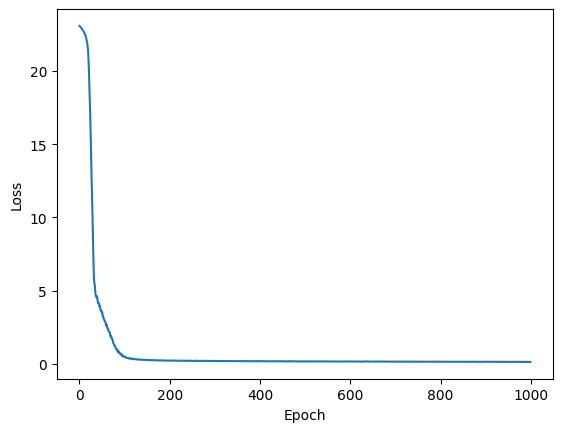

In [146]:
import matplotlib.pyplot as plt

plt.plot(loss)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()